# AlloyTower — Exploratory Data Analysis
**Dataset:** `alloy_data_cleaned.csv`  
**Author:** Chukwuebuka Tshally-Okeke | Data Scientist  
**Project:** AlloyTower Centralized Data Platform

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 50)

sns.set_theme(style='whitegrid', palette='Blues_d', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
df = pd.read_csv('../data/raw/alloy_data_cleaned.csv', parse_dates=['last_sale_date'])
print(f'Shape: {df.shape}')
df.head()

Shape: (2090, 27)


,property_id,id,full_address,street_address,unit,city,state,zip_code,county,latitude,longitude,property_type,bedrooms,bathrooms,sqft,lot_size_sqft,year_built,last_sale_price,last_sale_date,days_since_sale,price_per_sqft,assessed_value,tax_year,annual_tax,owner_name,owner_occupied,assessor_id
0,P-100001,10001,"1924 Oak Ave, Honolulu, HI 46048",1924 Oak Ave,NaN,Honolulu,HI,46048,Honolulu,27.49,-144.86,Single Family,6,5.00,1312,10986,1974,"546,937.17",2025-03-26,384,416.87,"473,424.11",2024,"7,207.52",Emily Gonzalez,False,HI-HO-81426
1,P-100002,10002,"3711 Harbor View Blvd, Pittsburgh, PA 87236",3711 Harbor View Blvd,NaN,Pittsburgh,PA,87236,Allegheny,28.37,-81.37,Single Family,6,4.00,3387,7939,1939,"287,944.73",2017-09-20,3128,85.01,"259,431.97",2022,"3,258.24",Matthew Thompson,False,PA-AL-15695
2,P-100003,10003,"8885 Park Way, Apt 21C, Kansas City, MO 59615",8885 Park Way,Apt 21C,Kansas City,MO,59615,Jackson,23.09,-131.49,Townhouse,7,3.50,5329,8479,2010,"174,253.02",2018-11-13,2709,32.70,"151,316.00",2023,"2,999.49",Joseph Miller,True,MO-JA-69429
3,P-100004,10004,"6165 Hillcrest Ave, Bronx, NY 37460",6165 Hillcrest Ave,NaN,Bronx,NY,37460,Bronx,38.76,-95.94,Single Family,5,2.00,4975,16921,1951,"948,377.61",2022-01-10,1555,190.63,"835,505.83",2024,"18,381.13",Joseph Baker,True,NY-BR-17331
4,P-100005,10005,"625 Ridgewood Rd, Apt 14E, Tucson, AZ 62581",625 Ridgewood Rd,Apt 14E,Tucson,AZ,62581,Pima,28.10,-138.64,Townhouse,6,3.50,2341,13079,1983,"428,592.88",2019-01-27,2634,183.08,"401,872.50",2023,"3,888.34",Deborah Scott,True,AZ-PI-86622


---
## 1. Dataset Overview

In [3]:
# Dtypes
df.dtypes

property_id                object
id                          int64
full_address               object
street_address             object
unit                       object
city                       object
state                      object
zip_code                    int64
county                     object
latitude                  float64
longitude                 float64
property_type              object
bedrooms                    int64
bathrooms                 float64
sqft                        int64
lot_size_sqft               int64
year_built                  int64
last_sale_price           float64
last_sale_date     datetime64[ns]
days_since_sale             int64
price_per_sqft            float64
assessed_value            float64
tax_year                    int64
annual_tax                float64
owner_name                 object
owner_occupied               bool
assessor_id                object
dtype: object

In [4]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})

,missing_count,missing_%
property_id,0,0.00
id,0,0.00
full_address,0,0.00
street_address,0,0.00
unit,1038,49.67
city,0,0.00
state,0,0.00
zip_code,0,0.00
county,0,0.00
latitude,0,0.00


In [5]:
# Numeric summary
df.describe()

,id,zip_code,latitude,longitude,bedrooms,bathrooms,sqft,lot_size_sqft,year_built,last_sale_price,last_sale_date,days_since_sale,price_per_sqft,assessed_value,tax_year,annual_tax
count,"2,090.00","2,090.00","2,090.00","2,090.00","2,090.00","2,090.00","2,090.00","2,090.00","2,090.00","2,090.00",2090,"2,090.00","2,090.00","2,090.00","2,090.00","2,090.00"
mean,"11,111.93","54,229.13",34.22,-113.97,4.00,2.98,"3,746.04","9,783.40","1,971.92","781,993.22",2021-05-14 15:29:27.272727296,"1,795.35",255.24,"743,996.17","2,023.00","11,478.22"
min,"10,001.00","10,158.00",21.01,-156.99,1.00,1.00,605.00,813.00,"1,920.00","121,231.29",2016-04-18 00:00:00,3.00,20.47,"102,598.19","2,022.00","1,057.28"
25%,"10,556.50","31,731.50",27.71,-135.82,2.00,2.00,"2,335.25","6,814.25","1,946.00","388,230.31",2018-11-16 06:00:00,847.75,105.02,"362,043.97","2,022.00","5,003.59"
50%,"11,112.50","54,147.00",33.92,-114.56,4.00,3.00,"3,807.50","9,725.00","1,973.00","611,405.61",2021-05-17 00:00:00,"1,793.00",171.88,"583,633.81","2,023.00","8,000.32"
75%,"11,667.75","75,996.25",40.98,-91.44,6.00,4.00,"5,228.75","12,732.25","1,997.00","838,723.75",2023-12-18 06:00:00,"2,705.75",350.64,"800,004.09","2,024.00","12,882.76"
max,"12,226.00","99,864.00",47.46,-70.00,7.00,5.00,"6,498.00","18,413.00","2,023.00","3,495,036.42",2026-04-11 00:00:00,"3,648.00",997.71,"3,610,723.16","2,024.00","79,316.93"
std,641.85,"25,672.13",7.62,25.34,2.00,1.31,"1,661.26","3,839.00",29.72,"655,877.06",NaN,"1,058.02",213.51,"638,886.67",0.81,"11,321.70"


In [6]:
# Categorical summary
cat_cols = ['property_type', 'city', 'state', 'county']
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique values')

property_type: 4 unique values
city: 84 unique values
state: 33 unique values
county: 80 unique values


---
## 2. Target Variable — `last_sale_price`

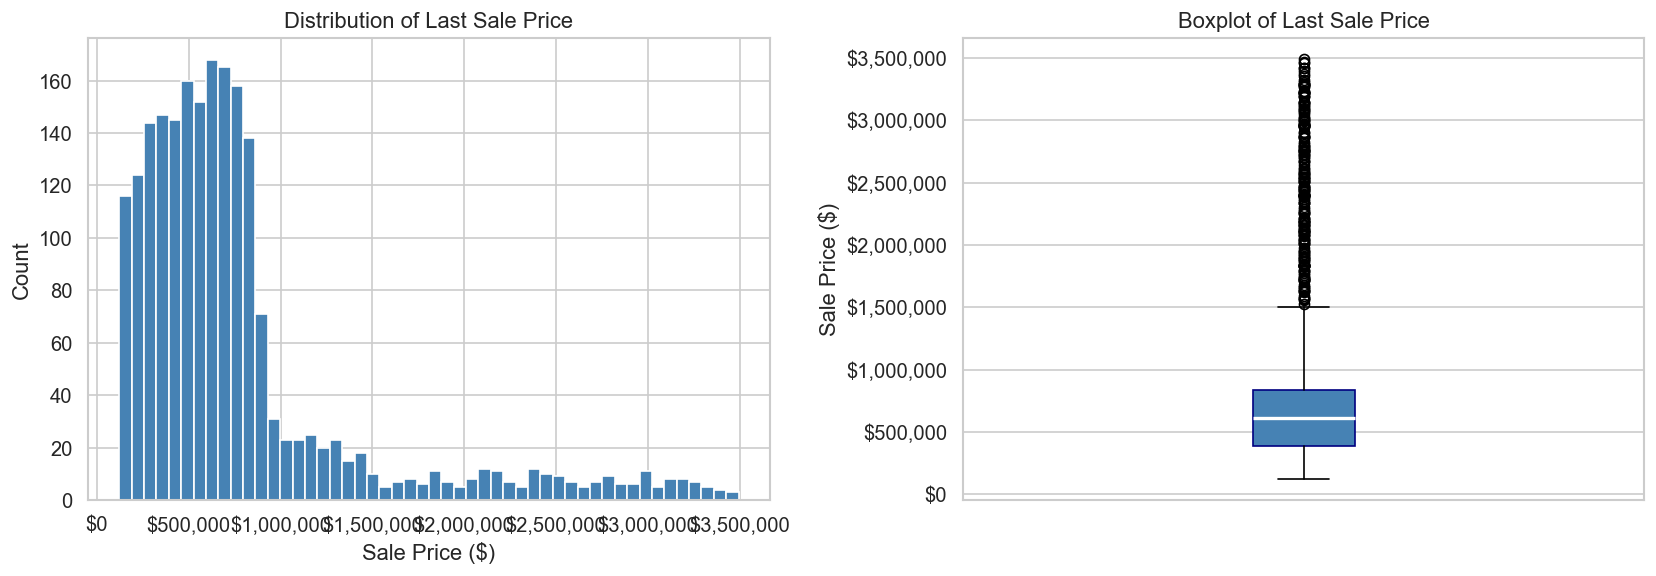

Mean:   $     781,993.22
Median: $     611,405.61
Std:    $     655,877.06
Min:    $     121,231.29
Max:    $   3,495,036.42


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['last_sale_price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Last Sale Price')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Boxplot
axes[1].boxplot(df['last_sale_price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_title('Boxplot of Last Sale Price')
axes[1].set_ylabel('Sale Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f"Mean:   ${df['last_sale_price'].mean():>15,.2f}")
print(f"Median: ${df['last_sale_price'].median():>15,.2f}")
print(f"Std:    ${df['last_sale_price'].std():>15,.2f}")
print(f"Min:    ${df['last_sale_price'].min():>15,.2f}")
print(f"Max:    ${df['last_sale_price'].max():>15,.2f}")

In [8]:
# Outlier check — properties above $2M
high_value = df[df['last_sale_price'] > 2_000_000]
print(f'Properties above $2M: {len(high_value)} ({len(high_value)/len(df)*100:.1f}%)')
high_value[['city', 'state', 'property_type', 'bedrooms', 'sqft', 'last_sale_price']].sort_values('last_sale_price', ascending=False).head(10)

Properties above $2M: 166 (7.9%)


,city,state,property_type,bedrooms,sqft,last_sale_price
652,Manhattan,NY,Single Family,7,3995,"3,495,036.42"
1367,San Francisco,CA,Single Family,7,4868,"3,470,501.71"
1969,Seattle,WA,Multi Family,7,4474,"3,462,480.32"
1728,Irvine,CA,Single Family,1,4727,"3,420,666.60"
929,Boston,MA,Single Family,6,5261,"3,417,076.78"
1768,Boston,MA,Townhouse,2,4472,"3,399,396.61"
911,San Diego,CA,Multi Family,5,6174,"3,368,792.37"
75,Manhattan,NY,Multi Family,2,4888,"3,357,881.22"
542,Irvine,CA,Townhouse,7,4233,"3,321,352.31"
1357,Cambridge,MA,Townhouse,5,3461,"3,303,778.23"


---
## 3. Property Type Analysis

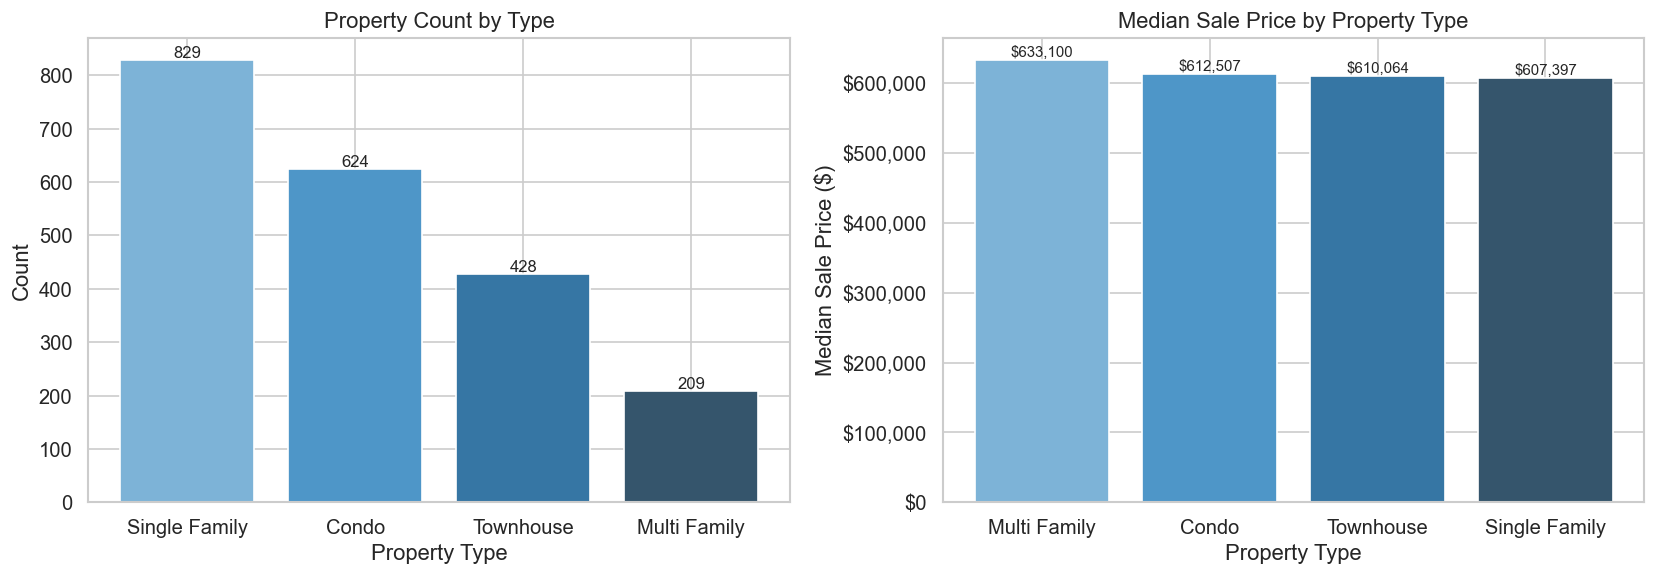

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
counts = df['property_type'].value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette('Blues_d', len(counts)))
axes[0].set_title('Property Count by Type')
axes[0].set_xlabel('Property Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

# Median price by type
median_price = df.groupby('property_type')['last_sale_price'].median().sort_values(ascending=False)
axes[1].bar(median_price.index, median_price.values, color=sns.color_palette('Blues_d', len(median_price)))
axes[1].set_title('Median Sale Price by Property Type')
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Median Sale Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(median_price.values):
    axes[1].text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

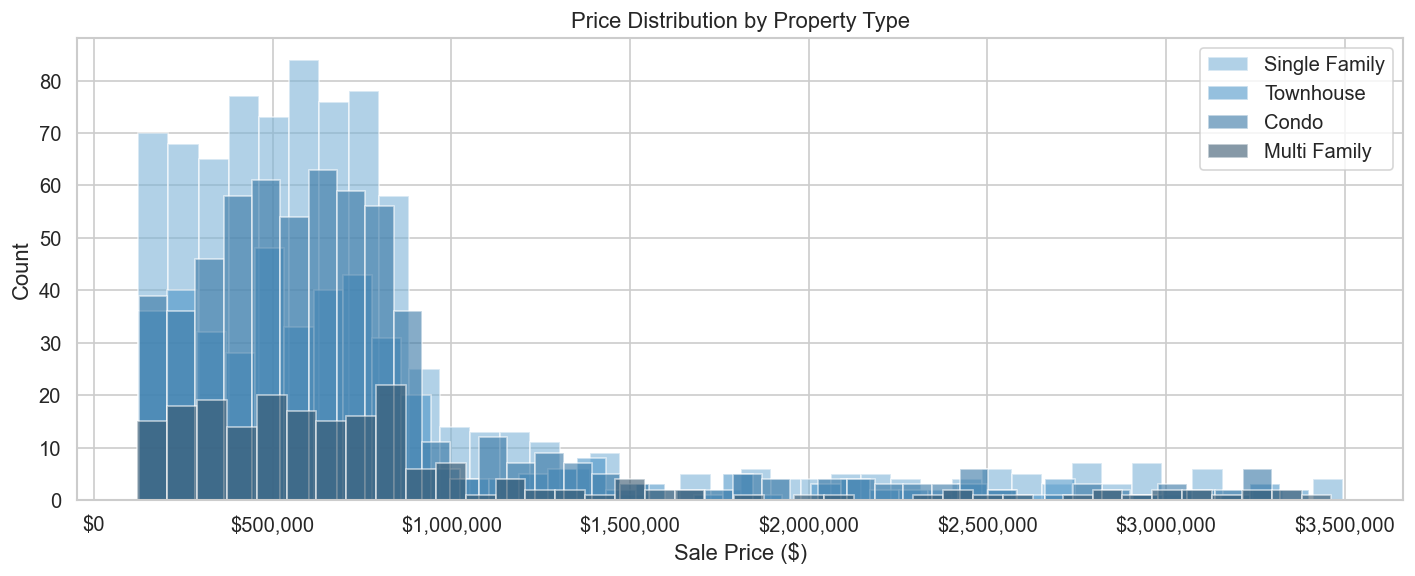

In [10]:
# Price distribution by property type
fig, ax = plt.subplots(figsize=(12, 5))
for ptype, color in zip(df['property_type'].unique(), sns.color_palette('Blues_d', 4)):
    subset = df[df['property_type'] == ptype]['last_sale_price']
    ax.hist(subset, bins=40, alpha=0.6, label=ptype, color=color)
ax.set_title('Price Distribution by Property Type')
ax.set_xlabel('Sale Price ($)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Geographic Analysis

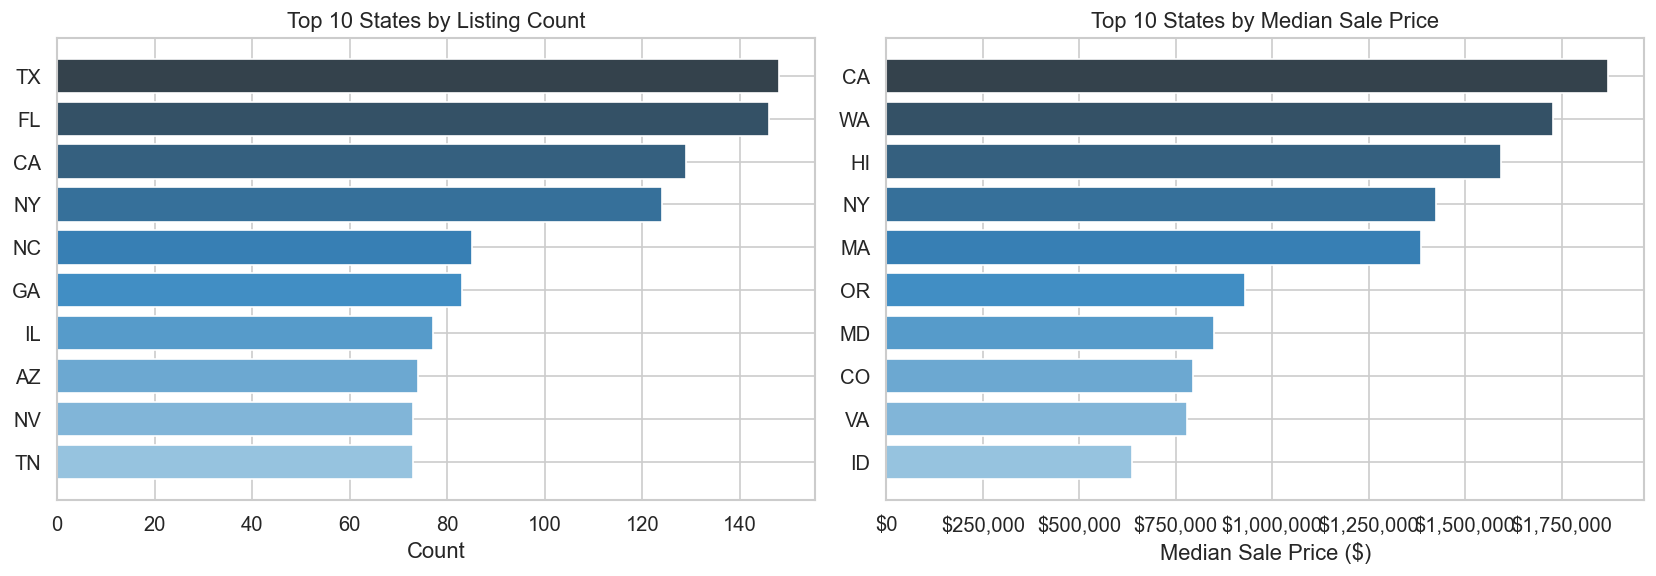

In [11]:
# Top 10 states by listing count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_states_count = df['state'].value_counts().head(10)
axes[0].barh(top_states_count.index[::-1], top_states_count.values[::-1],
             color=sns.color_palette('Blues_d', 10))
axes[0].set_title('Top 10 States by Listing Count')
axes[0].set_xlabel('Count')

# Top 10 states by median price
top_states_price = df.groupby('state')['last_sale_price'].median().sort_values(ascending=False).head(10)
axes[1].barh(top_states_price.index[::-1], top_states_price.values[::-1],
             color=sns.color_palette('Blues_d', 10))
axes[1].set_title('Top 10 States by Median Sale Price')
axes[1].set_xlabel('Median Sale Price ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

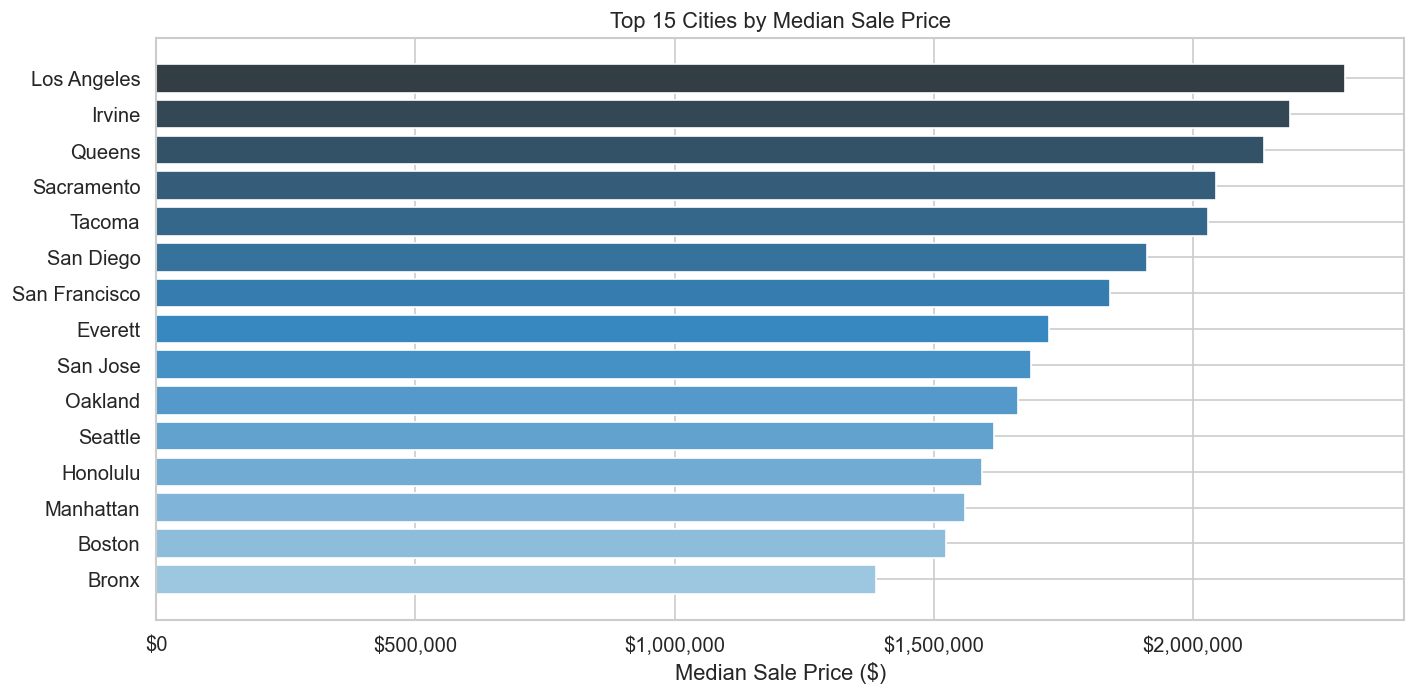

In [12]:
# Top 15 cities by median price
top_cities = df.groupby('city')['last_sale_price'].median().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_cities.index[::-1], top_cities.values[::-1],
        color=sns.color_palette('Blues_d', 15))
ax.set_title('Top 15 Cities by Median Sale Price')
ax.set_xlabel('Median Sale Price ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 5. Numeric Feature Distributions

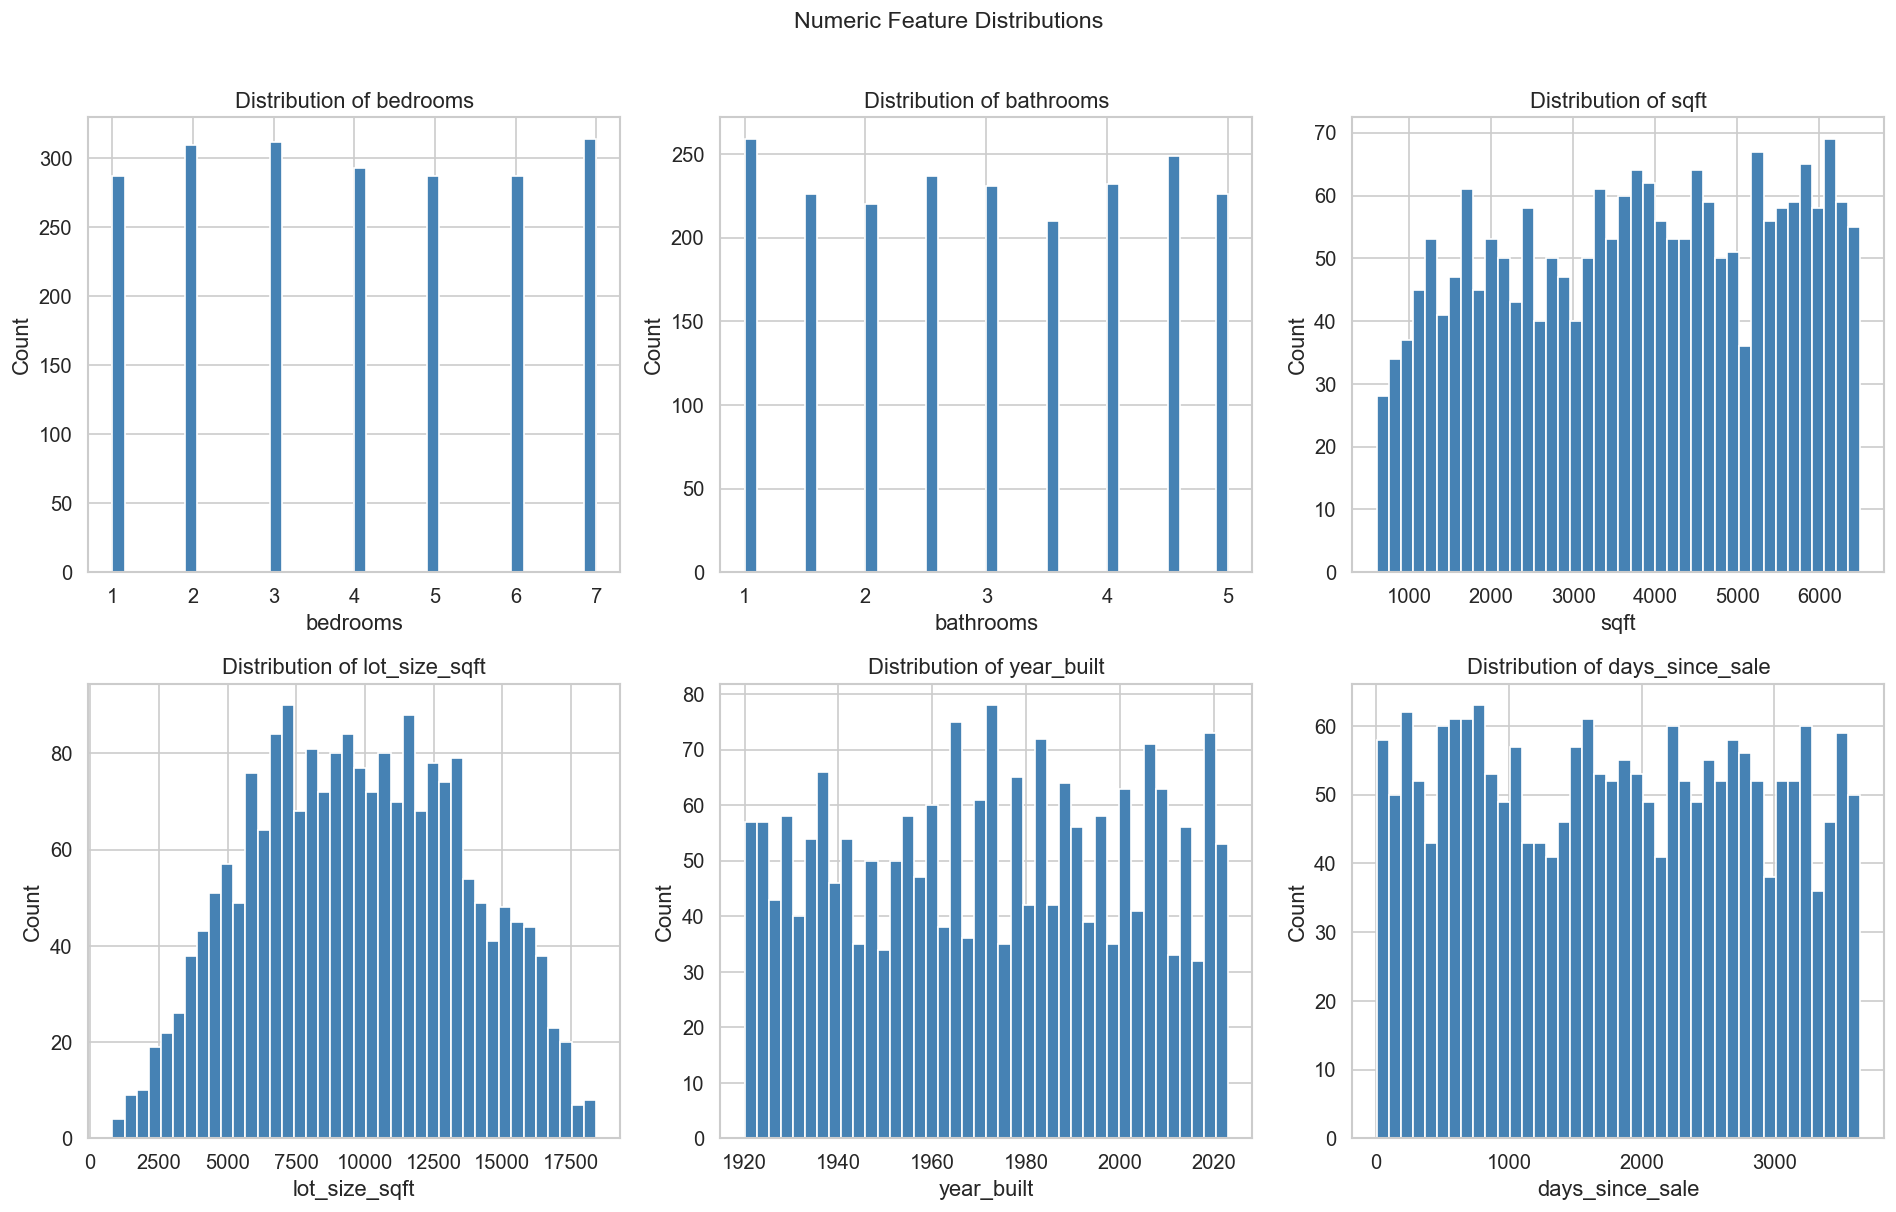

In [13]:
numeric_features = ['bedrooms', 'bathrooms', 'sqft', 'lot_size_sqft', 'year_built', 'days_since_sale']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

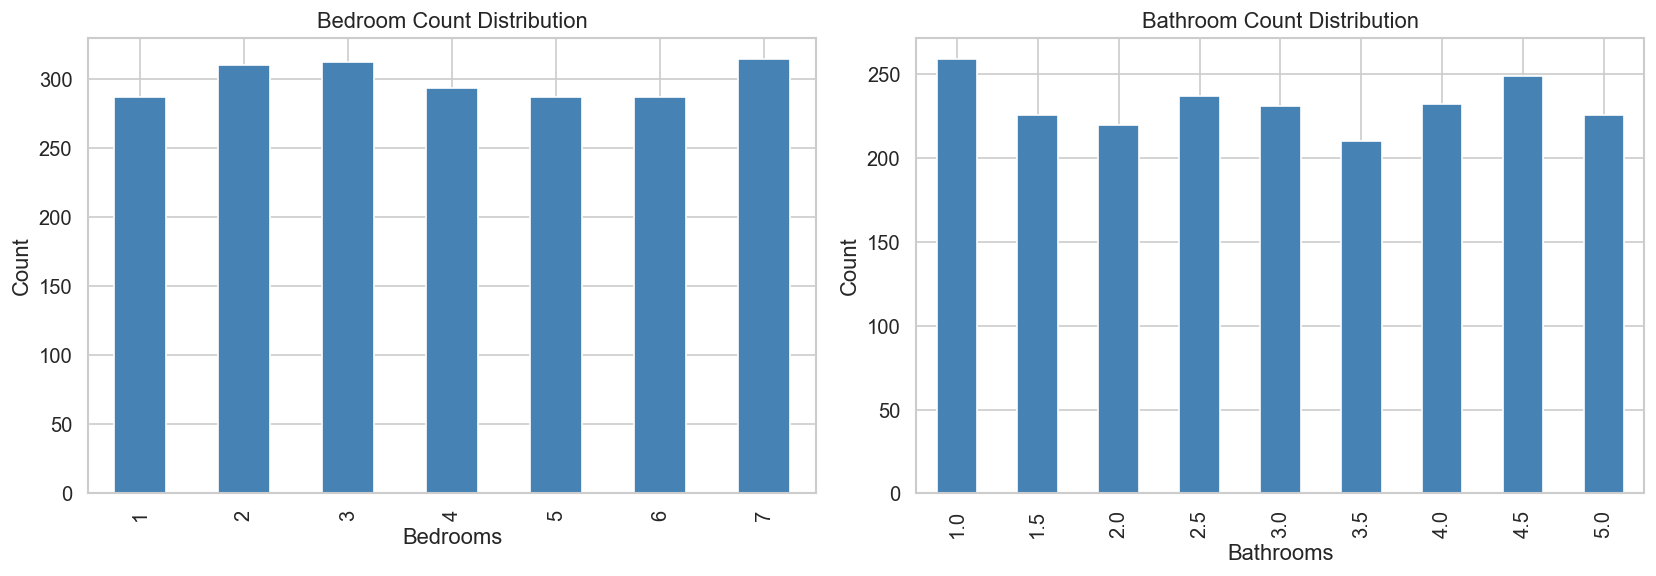

In [14]:
# Bedrooms and bathrooms value counts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['bedrooms'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Bedroom Count Distribution')
axes[0].set_xlabel('Bedrooms')
axes[0].set_ylabel('Count')

df['bathrooms'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Bathroom Count Distribution')
axes[1].set_xlabel('Bathrooms')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## 6. Feature Relationships with Target

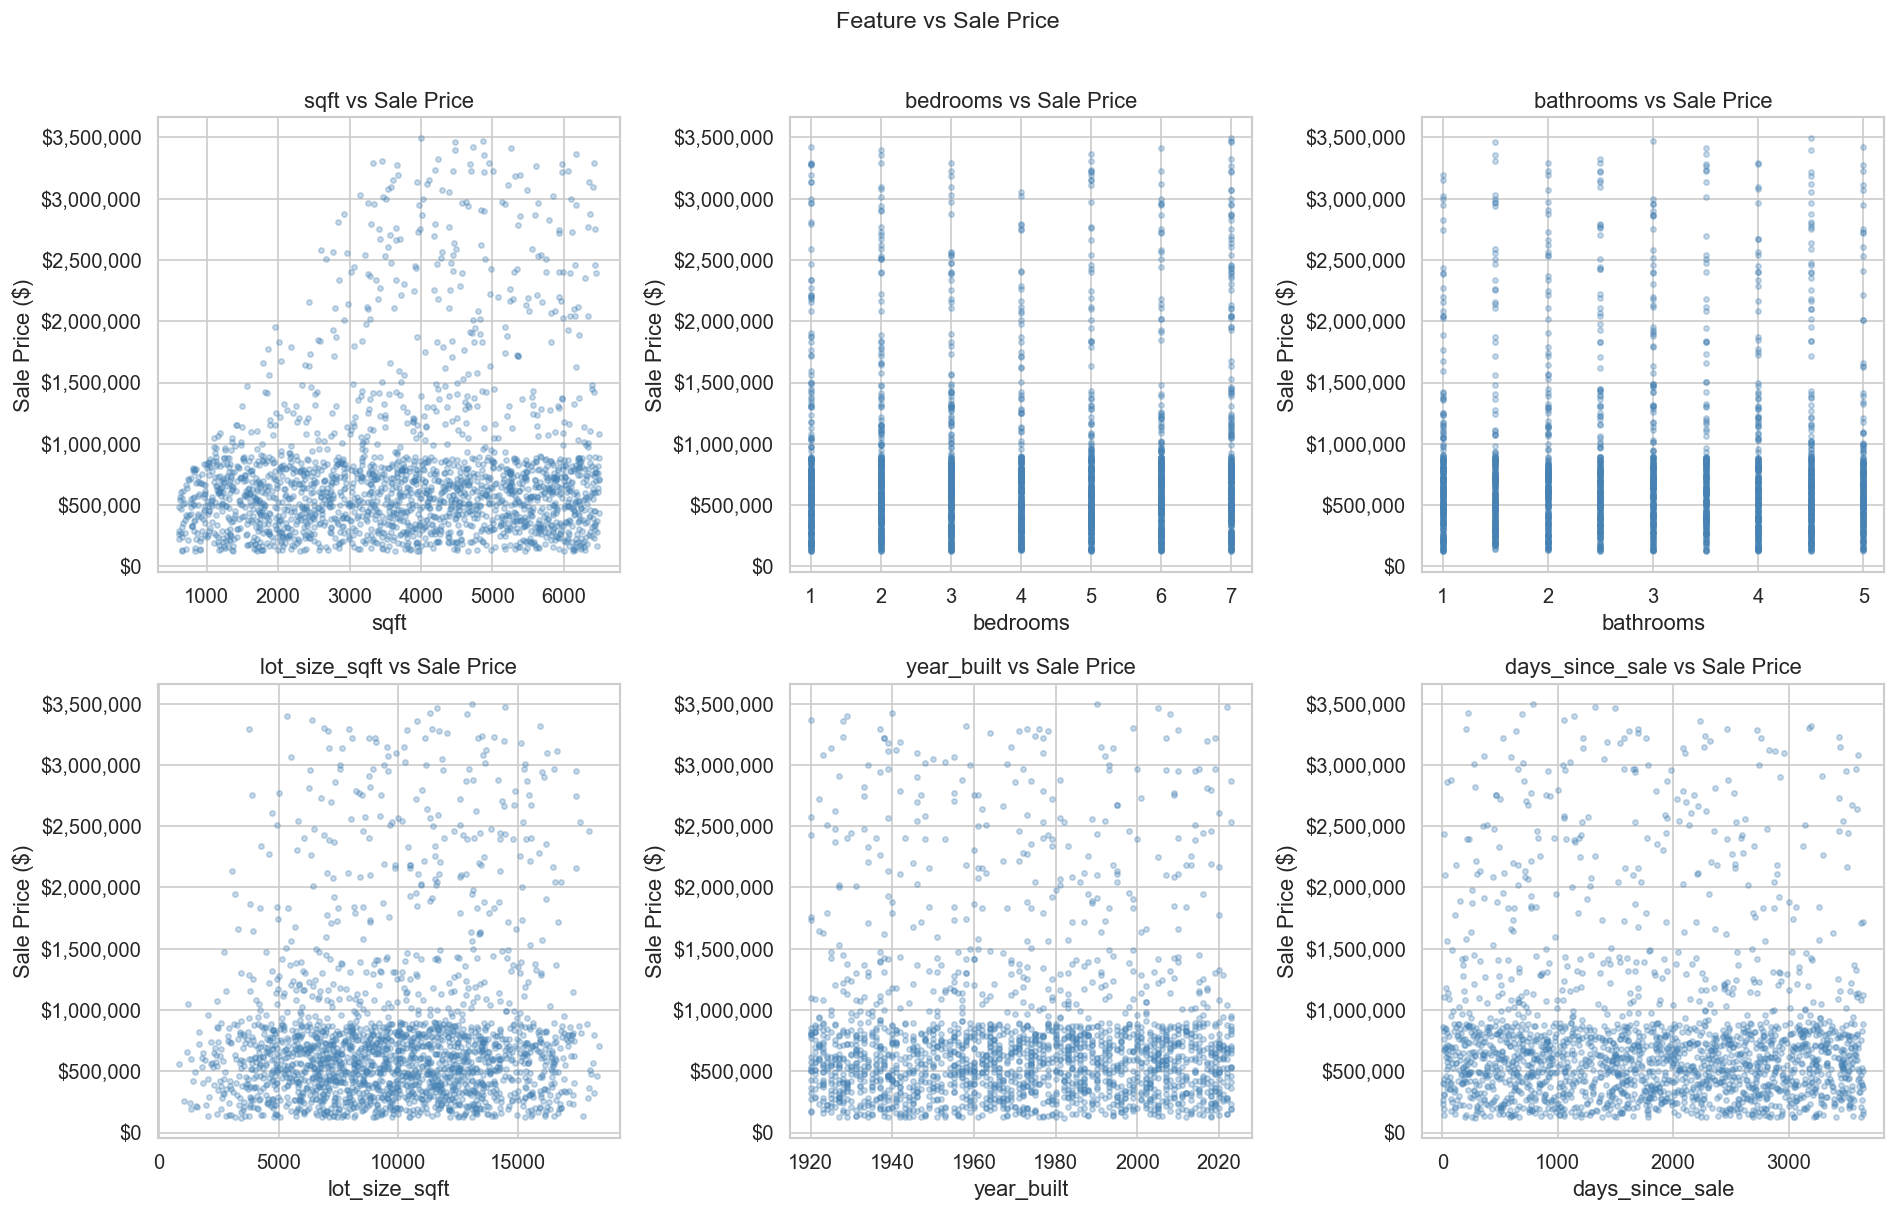

In [15]:
# Scatter plots of key numeric features vs last_sale_price
scatter_features = ['sqft', 'bedrooms', 'bathrooms', 'lot_size_sqft', 'year_built', 'days_since_sale']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(scatter_features):
    axes[i].scatter(df[col], df['last_sale_price'], alpha=0.3, color='steelblue', s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Sale Price ($)')
    axes[i].set_title(f'{col} vs Sale Price')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Feature vs Sale Price', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

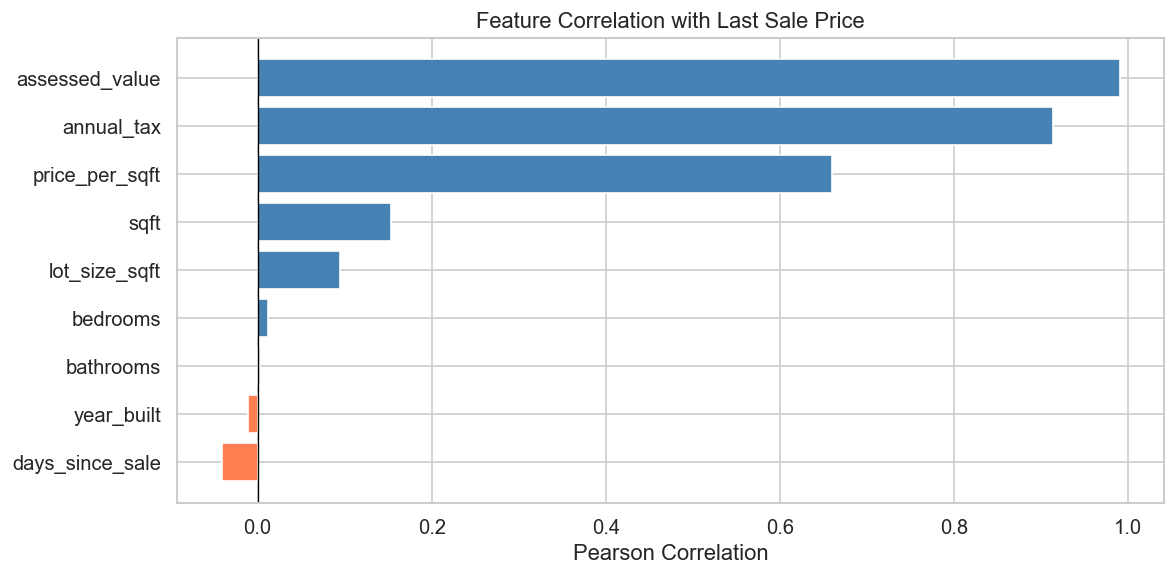

assessed_value     0.99
annual_tax         0.91
price_per_sqft     0.66
sqft               0.15
lot_size_sqft      0.10
bedrooms           0.01
bathrooms          0.00
year_built        -0.01
days_since_sale   -0.04
Name: last_sale_price, dtype: float64


In [16]:
# Correlation with target
numeric_cols = ['bedrooms', 'bathrooms', 'sqft', 'lot_size_sqft', 'year_built',
                'days_since_sale', 'price_per_sqft', 'assessed_value', 'annual_tax', 'last_sale_price']

corr_with_target = df[numeric_cols].corr()['last_sale_price'].drop('last_sale_price').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if v >= 0 else 'coral' for v in corr_with_target.values]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors[::-1])
ax.set_title('Feature Correlation with Last Sale Price')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(corr_with_target)

---
## 7. Leakage Investigation — `assessed_value` & `annual_tax`

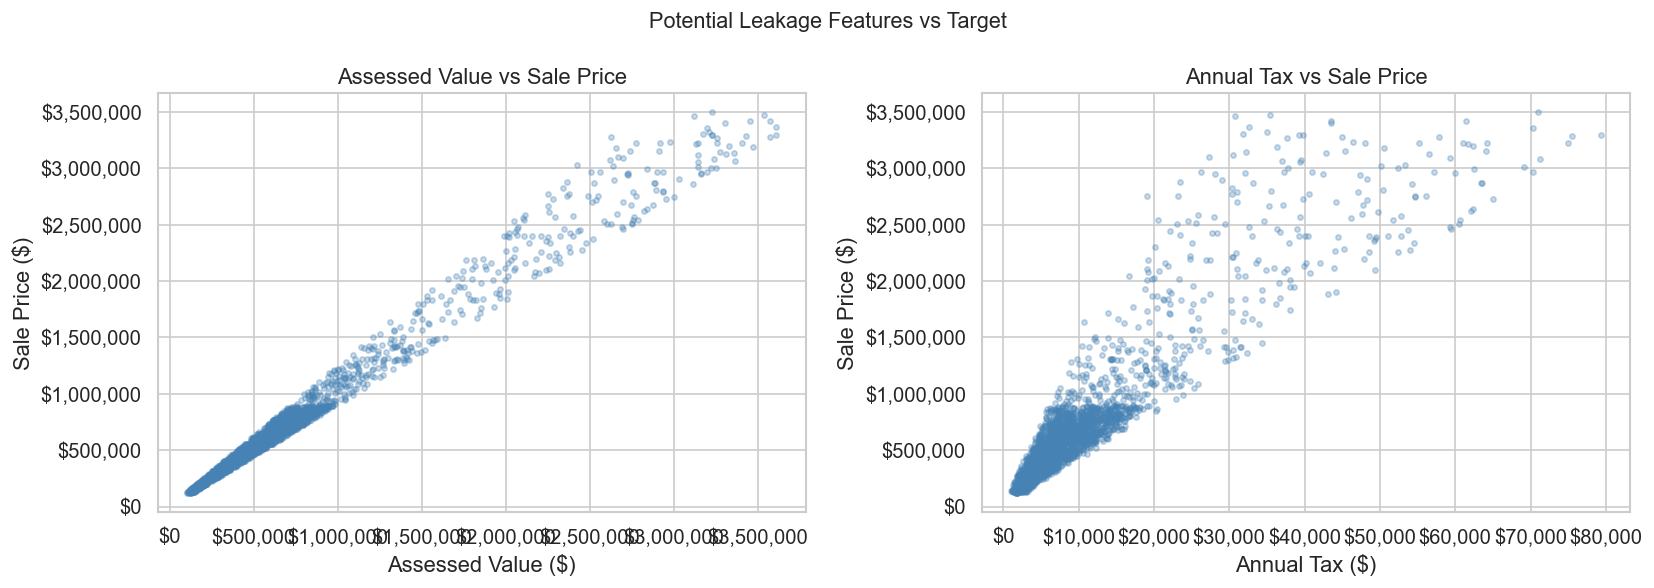

assessed_value correlation with last_sale_price: 0.9901
annual_tax correlation with last_sale_price:     0.9132


In [17]:
# High correlation with target is expected — these are derived from sale price
# Visualise the relationship
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['assessed_value'], df['last_sale_price'], alpha=0.3, color='steelblue', s=10)
axes[0].set_title('Assessed Value vs Sale Price')
axes[0].set_xlabel('Assessed Value ($)')
axes[0].set_ylabel('Sale Price ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].scatter(df['annual_tax'], df['last_sale_price'], alpha=0.3, color='steelblue', s=10)
axes[1].set_title('Annual Tax vs Sale Price')
axes[1].set_xlabel('Annual Tax ($)')
axes[1].set_ylabel('Sale Price ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Potential Leakage Features vs Target', fontsize=13)
plt.tight_layout()
plt.show()

print(f"assessed_value correlation with last_sale_price: {df['assessed_value'].corr(df['last_sale_price']):.4f}")
print(f"annual_tax correlation with last_sale_price:     {df['annual_tax'].corr(df['last_sale_price']):.4f}")

---
## 8. Correlation Heatmap

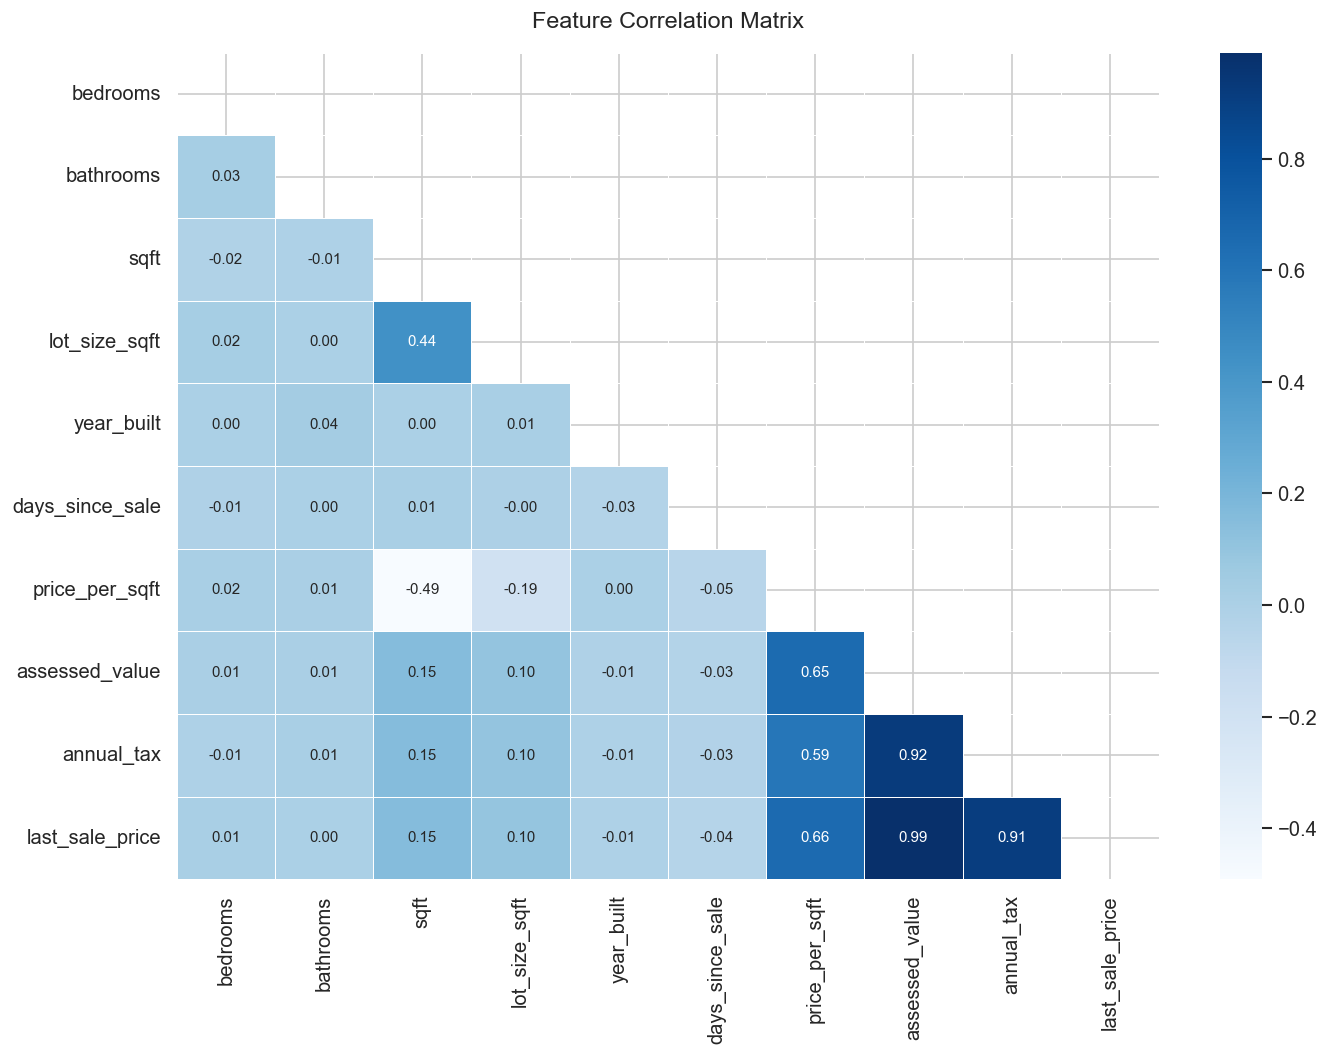

In [18]:
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='Blues', ax=ax, linewidths=0.5,
    annot_kws={'size': 9}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

---
## 9. Owner Occupancy Analysis

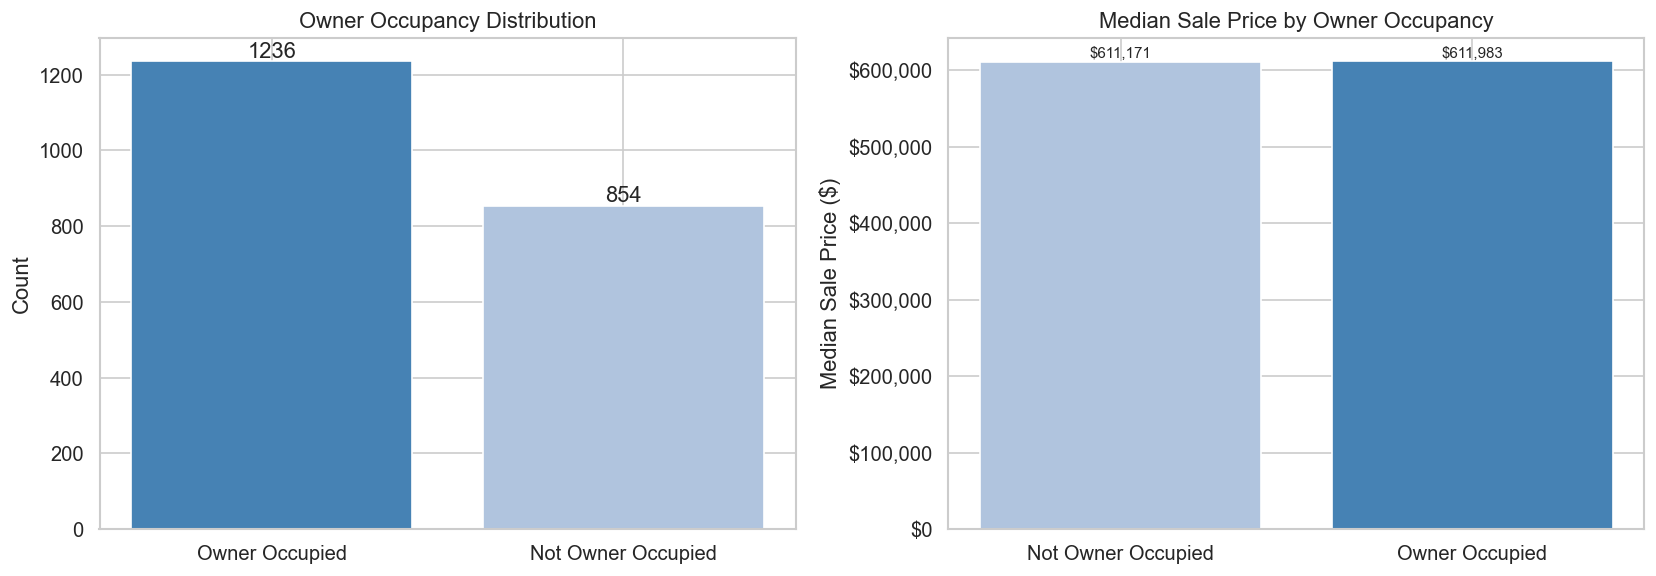

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
occ_counts = df['owner_occupied'].value_counts()
axes[0].bar(['Owner Occupied', 'Not Owner Occupied'], occ_counts.values,
            color=['steelblue', 'lightsteelblue'], edgecolor='white')
axes[0].set_title('Owner Occupancy Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(occ_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center')

# Median price by occupancy
occ_price = df.groupby('owner_occupied')['last_sale_price'].median()
axes[1].bar(['Not Owner Occupied', 'Owner Occupied'], occ_price.values,
            color=['lightsteelblue', 'steelblue'], edgecolor='white')
axes[1].set_title('Median Sale Price by Owner Occupancy')
axes[1].set_ylabel('Median Sale Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(occ_price.values):
    axes[1].text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 10. Sale Date Analysis

Earliest Sale: 2016
Latest Sale:   2026


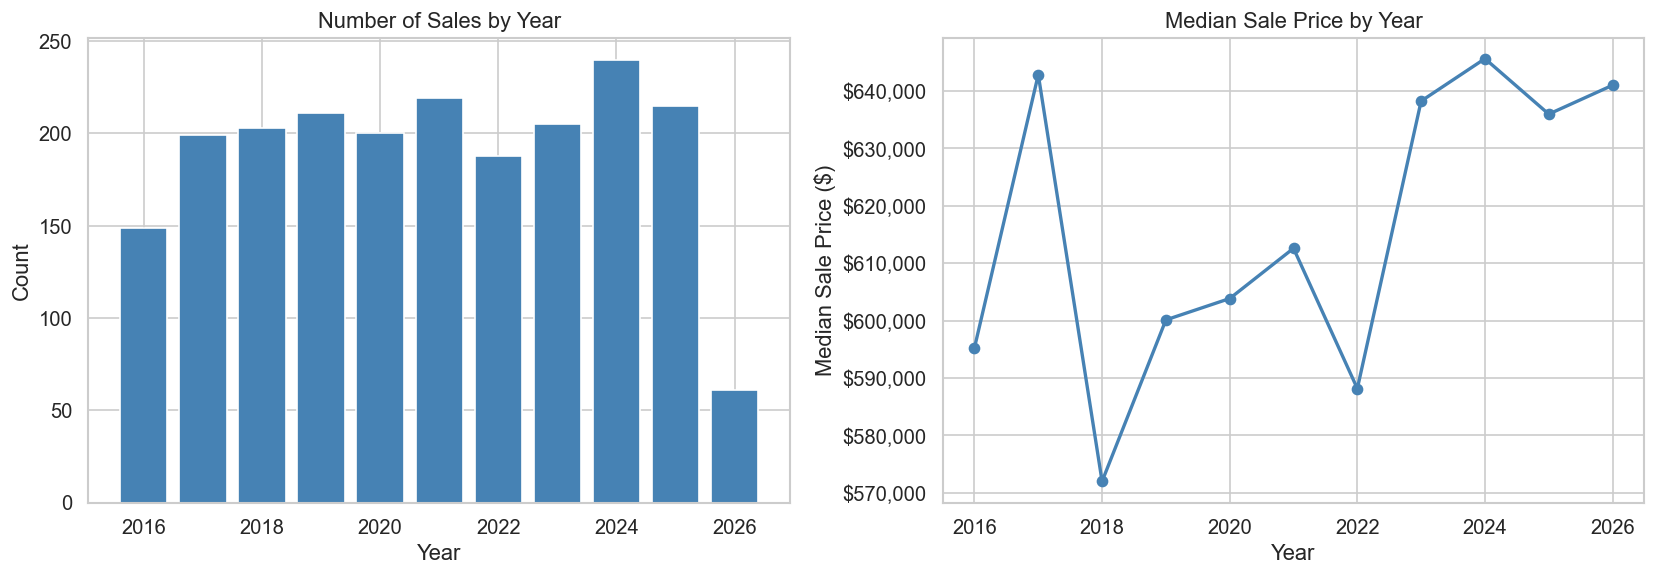

In [20]:
df['sale_year']  = df['last_sale_date'].dt.year
df['sale_month'] = df['last_sale_date'].dt.month

print(f"Earliest Sale: {df['last_sale_date'].min().year}")
print(f"Latest Sale:   {df['last_sale_date'].max().year}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales by year
sales_by_year = df['sale_year'].value_counts().sort_index()
axes[0].bar(sales_by_year.index, sales_by_year.values, color='steelblue', edgecolor='white')
axes[0].set_title('Number of Sales by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

# Median price by year
price_by_year = df.groupby('sale_year')['last_sale_price'].median()
axes[1].plot(price_by_year.index, price_by_year.values, marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Median Sale Price by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Sale Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

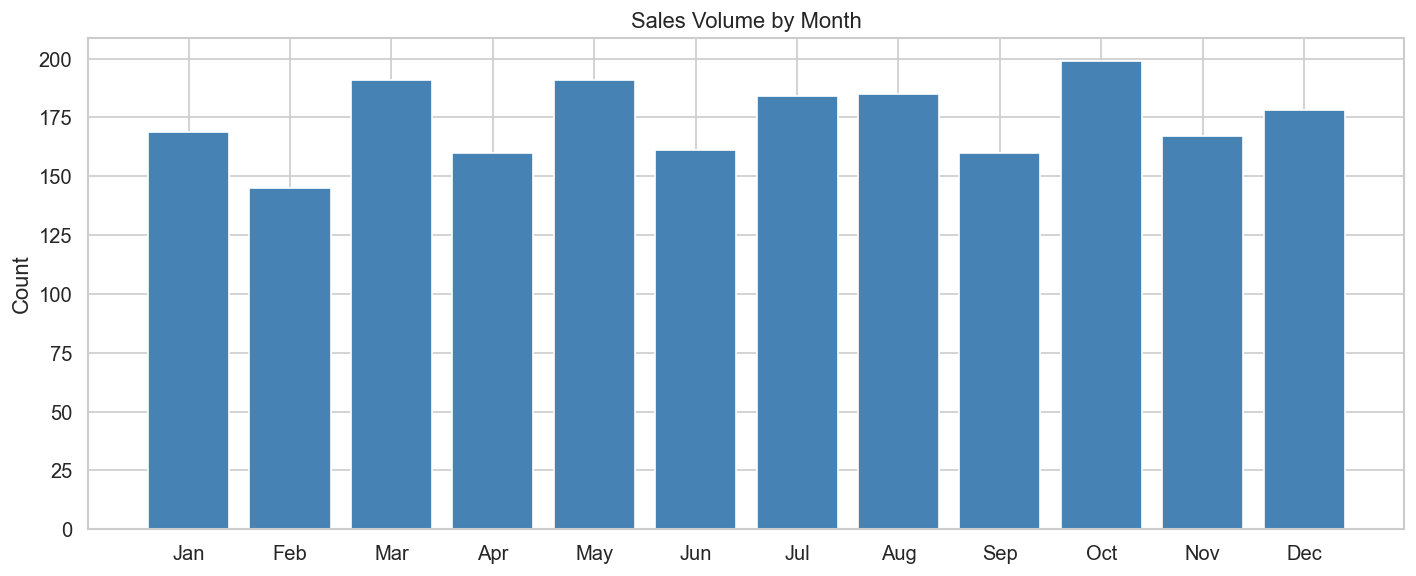

In [21]:
# Sales volume by month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sales_by_month = df['sale_month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, 13), [sales_by_month.get(m, 0) for m in range(1, 13)],
       color='steelblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('Sales Volume by Month')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Drop helper columns
df.drop(columns=['sale_year', 'sale_month'], inplace=True)

---
## 11. Price per Sqft Analysis

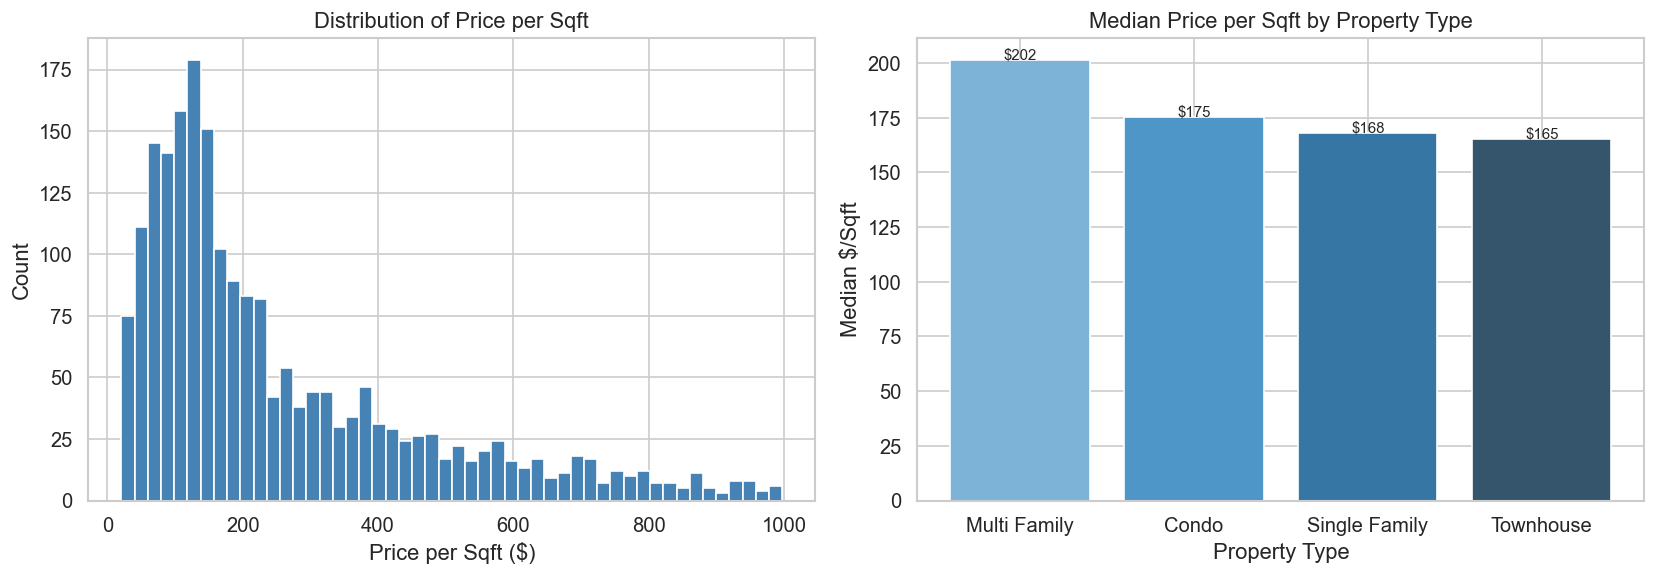

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['price_per_sqft'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Price per Sqft')
axes[0].set_xlabel('Price per Sqft ($)')
axes[0].set_ylabel('Count')

# By property type
ppsf_by_type = df.groupby('property_type')['price_per_sqft'].median().sort_values(ascending=False)
axes[1].bar(ppsf_by_type.index, ppsf_by_type.values,
            color=sns.color_palette('Blues_d', len(ppsf_by_type)))
axes[1].set_title('Median Price per Sqft by Property Type')
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Median $/Sqft')
for i, v in enumerate(ppsf_by_type.values):
    axes[1].text(i, v + 0.5, f'${v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 12. EDA Summary

| Finding | Detail |
|---|---|
| Dataset size | 2,090 rows, 27 columns |
| Missing values | Only `unit` column (expected — not all properties have units) |
| Target skew | `last_sale_price` is right-skewed — outliers above $2M exist |
| Strongest predictors | `assessed_value`, `annual_tax`, `price_per_sqft`, `sqft` |
| Leakage risk | `assessed_value` and `annual_tax` are highly correlated with target — flag for feature engineering |
| Property type | Single Family dominates (40%) — Multi Family has highest median price |
| Geography | TX, FL, CA, NY are top states by listing volume |
| Seasonality | Sale volume peaks in spring/summer months |
| Coordinate quality | Some lat/long values appear geographically inconsistent — flag for engineering |
